# Greedy vs GA with walking speed.

In [4]:
%load_ext autoreload
%autoreload 2

In [5]:
folder = 'outputs/runs/'

In [6]:
from utils.comparison_metrics import (
    build_results_table,
    extract_results,
    format_results_table,
    extract_cohens_d,
    calculate_poa,
    build_delta_table,
    plot_dispersion_all_cities,
    plot_metrics_by_human_behaviour
)
import pandas as pd

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

In [7]:
from utils.environment import Environment

grid = Environment('grid-like_topology')
moderate = Environment('moderate-complexity_topology')
bottleneck = Environment('bottleneck-constrained_topology')

graphs = {
    'Grid': grid.graph, 'Moderate': moderate.graph, 'Bottleneck': bottleneck.graph
}

positions = {
    'Grid': grid.pos, 'Moderate': moderate.pos, 'Bottleneck': bottleneck.pos
}


In [8]:
baseline_files = {
    'Grid':       f'{folder}grid_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Moderate':   f'{folder}moderate_city_Falsewalking_Falsedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Falsewalking_Falsedelay_1compliance.pkl',
}

# Comparisons

In [9]:
experiment_files_compliance = {
    'Grid': {
        0.0:  f'{folder}grid_city_Truewalking_Truedelay_0compliance.pkl',
        0.25: f'{folder}grid_city_Truewalking_Truedelay_025compliance.pkl',
        0.5:  f'{folder}grid_city_Truewalking_Truedelay_05compliance.pkl',
        0.75: f'{folder}grid_city_Truewalking_Truedelay_075compliance.pkl',
        1.0:  f'{folder}grid_city_Truewalking_Truedelay_1compliance.pkl',
    },
    'Moderate': {
        0.0:  f'{folder}moderate_city_Truewalking_Truedelay_0compliance.pkl',
        0.25: f'{folder}moderate_city_Truewalking_Truedelay_025compliance.pkl',
        0.5:  f'{folder}moderate_city_Truewalking_Truedelay_05compliance.pkl',
        0.75: f'{folder}moderate_city_Truewalking_Truedelay_075compliance.pkl',
        1.0:  f'{folder}moderate_city_Truewalking_Truedelay_1compliance.pkl',
    },
    'Bottleneck': {
        0.0:  f'{folder}bottleneck_city_Truewalking_Truedelay_0compliance.pkl',
        0.25: f'{folder}bottleneck_city_Truewalking_Truedelay_025compliance.pkl',
        0.5:  f'{folder}bottleneck_city_Truewalking_Truedelay_05compliance.pkl',
        0.75: f'{folder}bottleneck_city_Truewalking_Truedelay_075compliance.pkl',
        1.0:  f'{folder}bottleneck_city_Truewalking_Truedelay_1compliance.pkl',
    },
}

experiment_files = {
    'Grid': f'{folder}grid_city_Truewalking_Truedelay_1compliance.pkl',
    'Moderate':  f'{folder}moderate_city_Truewalking_Truedelay_1compliance.pkl',
    'Bottleneck': f'{folder}bottleneck_city_Truewalking_Truedelay_1compliance.pkl',
}

In [10]:
results = extract_results(experiment_files['Grid'])
print(f'Params: {results['ga']['params']}')   # {'walking': False, 'delay_start': False, ...}

Params: {'congestion': True, 'walking': True, 'delay_start': True, 'compliance': 1, 'fitness': 'max-median', 'alpha': 0.8}


### Initial Comparison

In [11]:
df = build_results_table(experiment_files)
formatted = format_results_table(df)
formatted.to_clipboard()
formatted

GA                                    Greedy  \
City                    Bottleneck          Grid      Moderate    Bottleneck   
Metric                                                                         
Average time          28.08 ± 1.12  14.83 ± 0.77  15.29 ± 0.64  25.85 ± 1.18   
Avg Congestion delay   9.56 ± 0.56   2.14 ± 0.18   2.28 ± 0.18   9.74 ± 0.58   
Avg Path Efficiency    1.05 ± 0.01   1.24 ± 0.02   1.14 ± 0.04   1.00 ± 0.00   
Avg path length       12.34 ± 0.26   8.65 ± 0.21   8.73 ± 0.35  10.52 ± 0.05   
Exit utilisation       0.20 ± 0.06   0.08 ± 0.04   0.07 ± 0.04   0.18 ± 0.05   
Total time            52.60 ± 2.06  27.30 ± 2.49  27.10 ± 1.64  54.00 ± 2.37   

                                                          p                   
City                          Grid      Moderate Bottleneck    Grid Moderate  
Metric                                                                        
Average time          10.02 ± 0.46  12.08 ± 0.41     0.002*  0.002*   0.002*  
Avg Congestion delay   2.21 ± 0.22   2.73 ± 0.18     0.014*   0.426   0.002*  
Avg Path Efficiency    1.00 ± 0.00   1.00 ± 0.00     0.002*  0.002*   0.002*  
Avg path length        5.00 ± 0.00   6.00 ± 0.05     0.002*  0.002*   0.002*  
Exit utilisation       0.20 ± 0.05   0.03 ± 0.02      0.508  0.002*   0.021*  
Total time            20.90 ± 1.14  25.60 ± 1.20     0.004*  0.002*   0.008*

In [12]:
extract_cohens_d(files=experiment_files)

Grid: d=3.56, p=0.002
Moderate: d=1.46, p=0.008
Bottleneck: d=-1.75, p=0.004


### Delta Table

In [13]:
delta_df = build_delta_table(baseline_files, experiment_files, 'Baseline', 'All')
pivot_table = delta_df.pivot(index=['Metric', 'Algorithm'], columns='City', values='Delta')
pivot_table.to_clipboard()
pivot_table

City                            Bottleneck   Grid  Moderate
Metric               Algorithm                             
Average time         GA               6.95   4.51      4.45
                     GREEDY           6.35   2.50      2.05
Avg Congestion delay GA               0.57  -0.11     -0.08
                     GREEDY           0.76  -0.31     -1.29
Avg Path Efficiency  GA              -0.01   0.06      0.03
                     GREEDY           0.00   0.00      0.00
Avg path length      GA               0.20   0.58      0.25
                     GREEDY           0.00   0.00      0.00
Exit utilisation     GA              -0.08   0.00     -0.03
                     GREEDY           0.00   0.00      0.00
Total time           GA              22.50  11.70     11.80
                     GREEDY          25.00   9.50     10.10

In [14]:
poa_df = calculate_poa(experiment_files)
poa_df['Ratio (Greedy/GA)']
# poa_df

Topology
Grid          0.766
Moderate      0.945
Bottleneck    1.027
Name: Ratio (Greedy/GA), dtype: float64

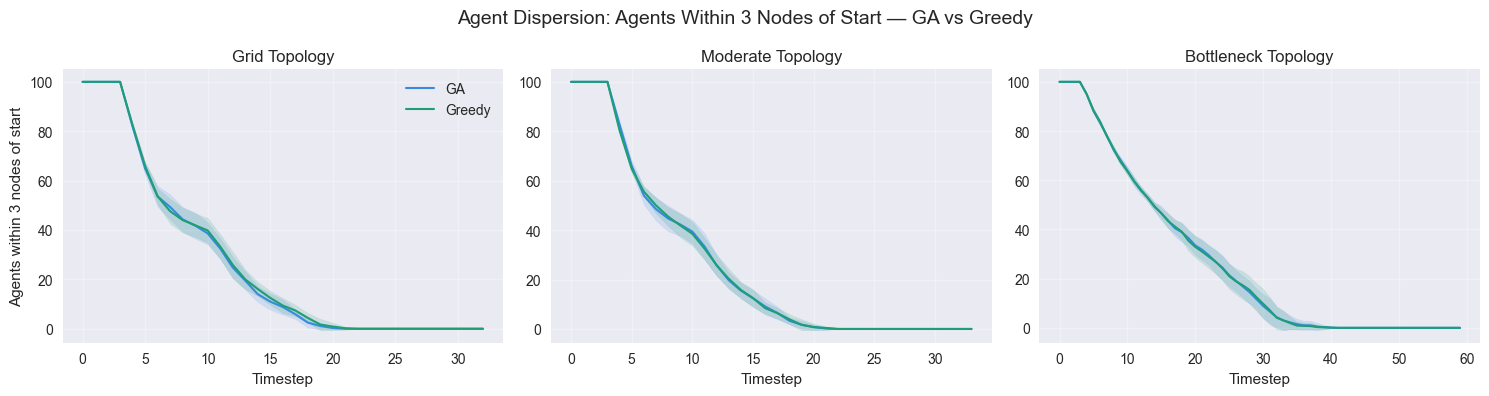

In [15]:
plot_dispersion_all_cities(experiment_files, n=3)

In [ ]:
plot_dispersion_all_cities(experiment_files, n=5)

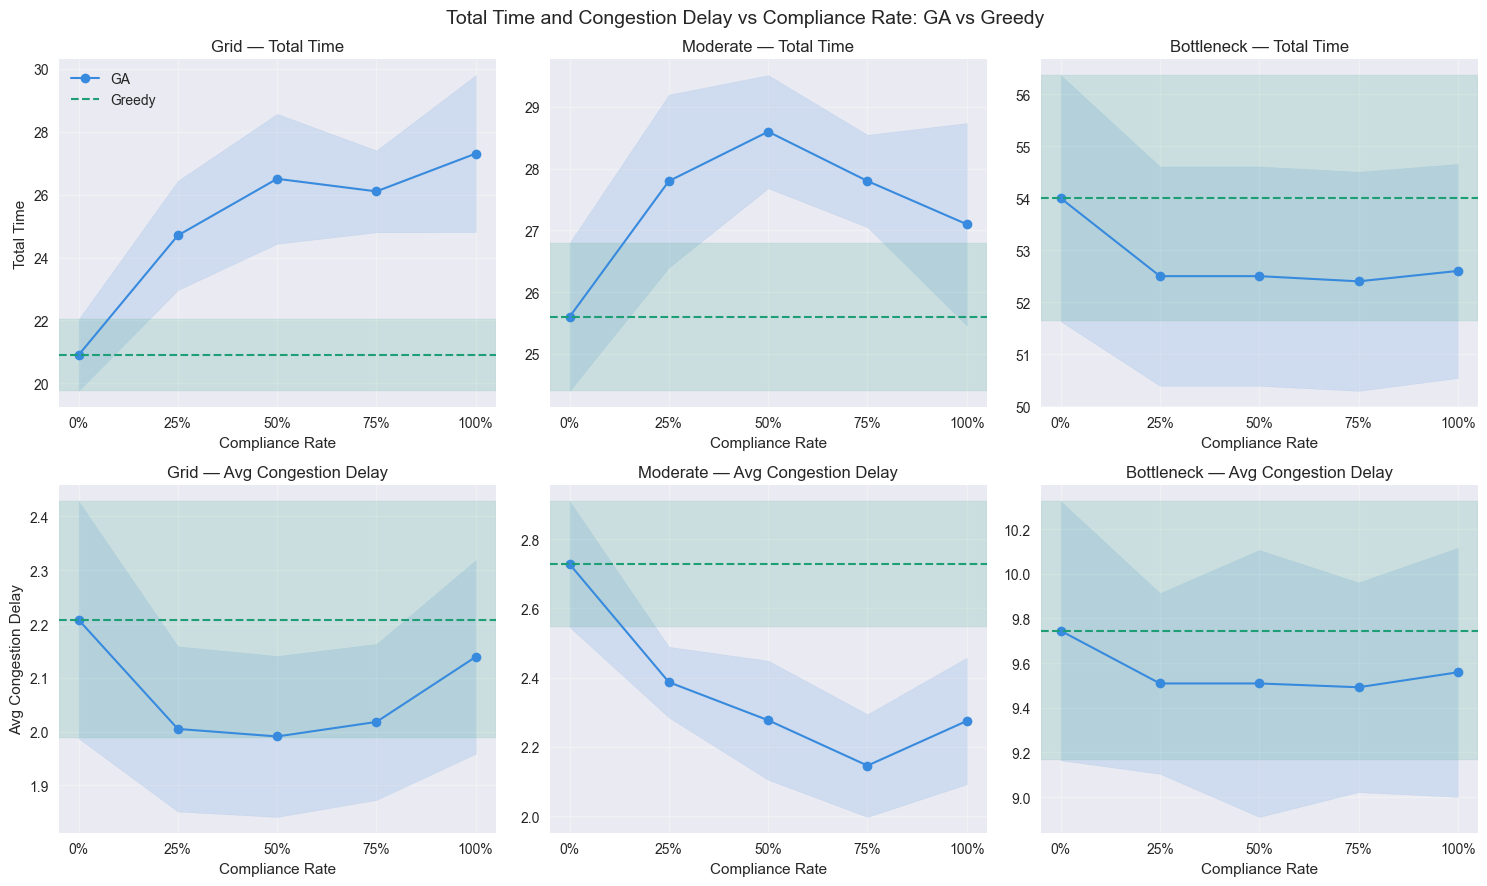

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_compliance_metrics(compliance_files: dict, baseline_files: dict) -> None:
    cities = list(compliance_files.keys())
    metrics = ['Total time', 'Avg Congestion delay']
    metric_labels = ['Total Time', 'Avg Congestion Delay']
    ga_colour = "#378ADD"
    greedy_colour = "#1D9E75"

    fig, axes = plt.subplots(2, len(cities), figsize=(5 * len(cities), 9))

    for row, (metric, label) in enumerate(zip(metrics, metric_labels)):
        for col, city in enumerate(cities):
            ax = axes[row, col]
            compliance_levels = sorted([k for k in compliance_files[city].keys() 
                                        if k != 0.0])

            # greedy from 100% compliance file - same human behaviour conditions as GA
            full_compliance_results = extract_results(compliance_files[city][1.0])
            greedy_vals = np.array([e.metrics[metric] 
                                    for e in full_compliance_results['greedy']['evals']])
            greedy_mean = greedy_vals.mean()
            greedy_std = greedy_vals.std()

            # GA values from compliance files
            ga_means, ga_stds = [], []
            for comp in compliance_levels:
                results = extract_results(compliance_files[city][comp])
                ga_vals = np.array([e.metrics[metric] for e in results['ga']['evals']])
                ga_means.append(ga_vals.mean())
                ga_stds.append(ga_vals.std())

            # prepend greedy mean as 0% compliance point
            all_levels = [0.0] + compliance_levels
            ga_means = np.array([greedy_mean] + ga_means)
            ga_stds = np.array([greedy_std] + ga_stds)

            ax.plot(all_levels, ga_means, color=ga_colour, linewidth=1.5,
                    marker='o', label='GA')
            ax.fill_between(all_levels, ga_means - ga_stds, ga_means + ga_stds,
                            alpha=0.15, color=ga_colour)

            ax.axhline(y=greedy_mean, color=greedy_colour, linewidth=1.5,
                       linestyle='--', label='Greedy')
            ax.axhspan(greedy_mean - greedy_std, greedy_mean + greedy_std,
                       alpha=0.15, color=greedy_colour)

            ax.set_title(f"{city} — {label}")
            ax.set_xlabel("Compliance Rate")
            ax.set_ylabel(label if col == 0 else "")
            ax.set_xticks(all_levels)
            ax.set_xticklabels([f"{int(c*100)}%" for c in all_levels])
            ax.grid(True, alpha=0.3)

            if row == 0 and col == 0:
                ax.legend()

    plt.suptitle("Total Time and Congestion Delay vs Compliance Rate: GA vs Greedy", fontsize=14)
    plt.tight_layout()
    plt.show()
    
    
plot_compliance_metrics(experiment_files_compliance, baseline_files)